In [228]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
import re
import nltk
from nltk.corpus import stopwords

In [16]:
df = pd.read_csv("G:/My Drive/Applied Data Science Mining - 502/Final Project/bbc_news_text_complexity_summarization.csv")

In [2]:
full_df = pd.read_csv("G:/My Drive/Final Project ADS 502/practice_df.csv")

full_df.drop('Unnamed: 0', inplace = True, axis = 1)

cosine_df = full_df.iloc[:, 6:31245]

cosine_vectors = cosine_df.values

cosine_matrix = cosine_similarity(cosine_vectors)

cosine_sim_df = pd.DataFrame(cosine_matrix, index = cosine_df.index, columns = cosine_df.index)

np.fill_diagonal(cosine_matrix, np.nan)

In [21]:
upper_half = np.triu(cosine_sim_df)
upper_df = pd.DataFrame(upper_half, columns = cosine_sim_df.columns, index = cosine_sim_df.index)

In [22]:
indicies = np.argwhere(upper_half > .8)

In [25]:
indicies

array([[ 208,  228],
       [ 251,  440],
       [ 257,  350],
       [ 264,  360],
       [ 283,  486],
       [ 287,  431],
       [ 553,  571],
       [ 560,  835],
       [ 564,  855],
       [ 581,  821],
       [ 602,  828],
       [ 641,  726],
       [ 676,  713],
       [ 875, 1192],
       [ 938, 1247],
       [ 940, 1175],
       [ 948, 1213],
       [ 952, 1165],
       [ 953, 1240],
       [ 959, 1199],
       [ 981, 1224],
       [ 996, 1155],
       [1067, 1164],
       [1083, 1191],
       [1097, 1135],
       [1107, 1203],
       [1322, 1360],
       [1384, 1393],
       [1453, 1454],
       [1559, 1676],
       [1572, 1584],
       [1582, 1685],
       [1598, 1599],
       [1602, 1614],
       [1655, 1657],
       [1693, 1779],
       [1694, 1702],
       [1696, 1777],
       [1701, 1706],
       [1712, 1726],
       [1735, 1739],
       [1737, 1738],
       [1746, 1747],
       [1757, 1758],
       [1786, 1838],
       [1788, 2110],
       [1798, 2069],
       [1801,

In [26]:
dup = []

for i, j in indicies:
    dup.append(i)

In [28]:
len(df)

2127

In [30]:
df.drop(index = dup, axis = 0, inplace = True)

In [31]:
len(df)

2058

In [42]:
full_df.drop(index = dup, axis = 0, inplace = True)

In [48]:
columns = full_df.iloc[:, 1:6]
full_df.drop(columns = columns, axis = 1, inplace = True)

In [49]:
full_df.head()

,labels,ad,sales,boost,time,warner,profitquarterly,profits,us,media,...,reccomend,counsellor,frag,relasing,hrs,enviroment,trifling,24hours,ahhhh,lol
0,business,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,business,0,0,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,business,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,business,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,business,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [80]:
stop_words = set(stopwords.words('english'))

In [99]:
new_adds = full_df.iloc[:, 1:31240].sum().sort_values(ascending = False).head(15)
new_adds = new_adds.index[0:16]
new_adds = new_adds.tolist()

In [102]:
stop_words.update(new_adds)

In [103]:
def clean(df):
    normalized_columns = [col.lower() for col in df.columns[1:]]  # Skip the first column (labels)

    # Identify stop word columns
    stop_word_columns = [df.columns[i + 1] for i, col in enumerate(normalized_columns) if col in stop_words]
    
    # Debugging: Print identified stop word columns
    print(f"Stop word columns to drop: {stop_word_columns}")

    # Drop stop word columns
    df.drop(columns=stop_word_columns, inplace=True)
    return df

# Assuming `full_df` is your DataFrame with the first column being the labels
full_df = clean(full_df)

Stop word columns to drop: ['time', 'us', 'year', 'one', 'said', 'also', 'new', 'mr', 'could', 'would', 'last', 'two', 'years', 'first', 'people']


In [109]:
sums = full_df.iloc[:, 1:31225].sum().sort_values(ascending = False)

In [113]:
columns_drop = sums.index[31184:]

In [114]:
full_df.drop(columns = columns_drop, inplace = True, axis = 1)

In [115]:
full_df.shape

(2058, 31185)

In [124]:
X = full_df.iloc[:, 1:31186]
X_constant = sm.add_constant(X)

y = full_df.iloc[:, [0]]

In [137]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .25, random_state = 5)

In [168]:
y_series = full_df.iloc[:, 0]
X_con_train, X_con_test, y_logit_train, y_logit_test = train_test_split(X_constant, y_series, test_size = .25, random_state = 3)

In [169]:
y_logit_train = y_logit_train.astype('category').cat.codes
y_logit_test = y_logit_test.astype('category').cat.codes

In [140]:
y_train = np.array(y_train).ravel()
y_test = np.array(y_test).ravel()

In [131]:
model = LogisticRegression(random_state = 4, multi_class = 'multinomial')

In [147]:
model = model.fit(X_train, y_train)

In [148]:
y_pred = model.predict(X_test)

In [149]:
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.97      0.98      0.97       117
entertainment       0.98      0.97      0.97        93
     politics       0.97      0.96      0.97       101
        sport       0.99      1.00      1.00       123
         tech       0.99      0.98      0.98        81

     accuracy                           0.98       515
    macro avg       0.98      0.98      0.98       515
 weighted avg       0.98      0.98      0.98       515



In [218]:
pca = PCA(n_components=350)  # Get 95% of the variance
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

X_train_pca_const = add_constant(X_train_pca)
X_test_pca_const = add_constant(X_test_pca)

In [219]:
model01 = sm.MNLogit(y_logit_train, X_train_pca_const)
result = model01.fit()

Optimization terminated successfully.
         Current function value: 1.032248
         Iterations 9


In [220]:
preds = result.predict(X_test_pca_const)

In [221]:
predicted_classes = np.argmax(preds, axis =1)

In [222]:
conf_mat = confusion_matrix(y_logit_test, predicted_classes)

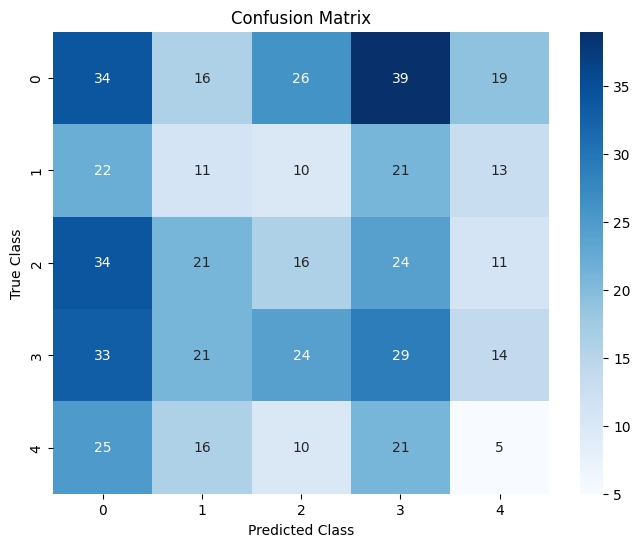

In [223]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix')
plt.show()

In [225]:
print(classification_report(y_logit_test, predicted_classes))

              precision    recall  f1-score   support

           0       0.23      0.25      0.24       134
           1       0.13      0.14      0.14        77
           2       0.19      0.15      0.17       106
           3       0.22      0.24      0.23       121
           4       0.08      0.06      0.07        77

    accuracy                           0.18       515
   macro avg       0.17      0.17      0.17       515
weighted avg       0.18      0.18      0.18       515



# SVM

In [229]:
svm_model = LinearSVC(C = 1, max_iter = 1000)

In [230]:
svm_model.fit(X_train, y_train)

C:\Users\Taylor\miniconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LinearSVC(C=1)

In [231]:
svm_preds = svm_model.predict(X_test)

In [232]:
print(classification_report(y_test, svm_preds))

               precision    recall  f1-score   support

     business       0.97      0.98      0.97       117
entertainment       1.00      0.96      0.98        93
     politics       0.95      0.97      0.96       101
        sport       1.00      1.00      1.00       123
         tech       0.99      0.99      0.99        81

     accuracy                           0.98       515
    macro avg       0.98      0.98      0.98       515
 weighted avg       0.98      0.98      0.98       515

